<a href="https://colab.research.google.com/github/AnnaNaumchuk/ecommerce-customer-segmentation-return-risk-analysis/blob/main/E_Commerce_Customer_Segmentation_%26_RFM_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 1. Завантаження датасету
df = pd.read_csv('ecommerce_sales_34500.csv')

# 2. Приведення колонки order_date до формату datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# 3. Перевірка базової інформації
print("Розмірність датасету:", df.shape)
print("\nПропущені значення:")
print(df.isnull().sum())
print("\nКількість дублікатів:", df.duplicated().sum())

Розмірність датасету: (34500, 17)

Пропущені значення:
order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

Кількість дублікатів: 0


In [ ]:
import pandas as pd

df = pd.read_csv('ecommerce_sales_34500.csv')

# 1. Загальні бізнес-метрики
total_revenue = df['total_amount'].sum()
total_profit = df['profit_margin'].sum()
aov = df['total_amount'].mean()

print(f"Загальний виторг: ${total_revenue:,.2f}")
print(f"Загальний чистий прибуток: ${total_profit:,.2f}")
print(f"Середній чек (AOV): ${aov:.2f}")

# 2. Аналіз повернень (Returns)
return_rate = (df['returned'] == 'Yes').mean() * 100
lost_revenue = df[df['returned'] == 'Yes']['total_amount'].sum()

print(f"Відсоток повернень: {return_rate:.2f}%")
print(f"Втрачений виторг через повернення: ${lost_revenue:,.2f}")

# 3. Збиткові замовлення
unprofitable_count = (df['profit_margin'] < 0).sum()
print(f"Кількість збиткових замовлень: {unprofitable_count} ({unprofitable_count/len(df)*100:.2f}%)")

Загальний виторг: $5,865,293.05
Загальний чистий прибуток: $970,019.41
Середній чек (AOV): $170.01
Відсоток повернень: 5.52%
Втрачений виторг через повернення: $388,755.97
Кількість збиткових замовлень: 6104 (17.69%)


In [ ]:
import pandas as pd

df = pd.read_csv('ecommerce_sales_34500.csv')
df['order_date'] = pd.to_datetime(df['order_date'])

# Фіксована дата аналізу (на 1 день пізніше за найновішу покупку в базі)
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

# Агрегація даних на рівень customer_id
customers = df.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('total_amount', 'sum'),
    Total_Profit=('profit_margin', 'sum'),
    Return_Rate=('returned', lambda x: (x == 'Yes').mean()),
    customer_age=('customer_age', 'first'),
    customer_gender=('customer_gender', 'first'),
    region=('region', lambda x: x.mode()[0]),
    Favorite_Category=('category', lambda x: x.mode()[0])
).reset_index()

print("Формат таблиці клієнтів:", customers.shape)

Формат таблиці клієнтів: (7903, 10)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Перевірка скошеності (Skewness)
skewness = customers[['Recency', 'Frequency', 'Monetary']].skew()
print("Асиметрія початкових метрик:")
print(skewness)

# 2. Логарифмування (Log Transformation) для усунення скошеності
rfm_log = customers[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

# 3. Стандартизація (StandardScaler)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']
)

Асиметрія початкових метрик:
Recency      1.367124
Frequency    0.550169
Monetary     3.370747
dtype: float64


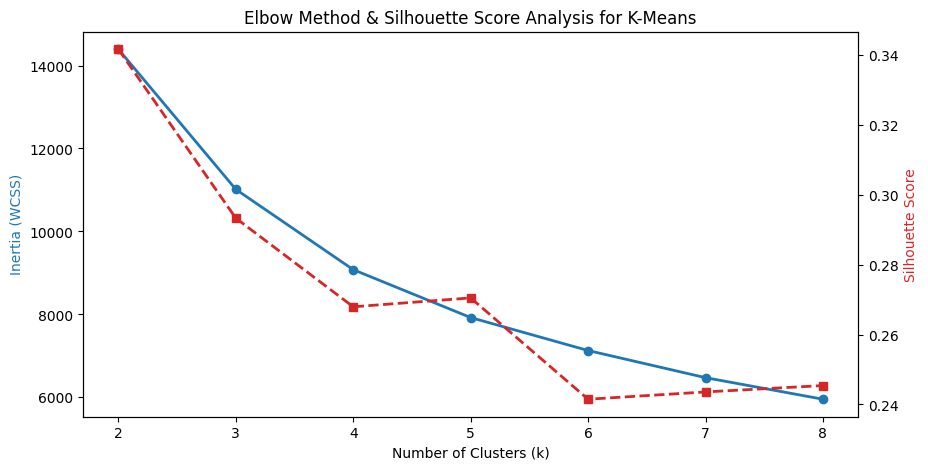

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Завантаження та підготовка даних
df = pd.read_csv('ecommerce_sales_34500.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

customers = df.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('total_amount', 'sum'),
    Total_Profit=('profit_margin', 'sum'),
    Return_Rate=('returned', lambda x: (x == 'Yes').mean())
).reset_index()

# 2. Логарифмування та стандартизація
rfm_log = customers[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# 3. Обчислення метрик для k від 2 до 8
k_range = range(2, 9)
inertia, silhouette_scores = [], []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# 4. Побудова суміщеного графіка
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)', color='tab:blue')
ax1.plot(k_range, inertia, marker='o', color='tab:blue', linewidth=2)

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(k_range, silhouette_scores, marker='s', color='tab:red', linestyle='--', linewidth=2)

plt.title('Elbow Method & Silhouette Score Analysis for K-Means')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Завантаження та підготовка цільової змінної
df = pd.read_csv('ecommerce_sales_34500.csv')
df['is_returned'] = (df['returned'] == 'Yes').astype(int)

# 2. Відбір ознак (Features) та One-Hot Encoding
features = ['category', 'price', 'discount', 'quantity', 'payment_method',
            'delivery_time_days', 'region', 'shipping_cost', 'profit_margin',
            'customer_age', 'customer_gender']

X = pd.get_dummies(df[features], drop_first=True)
y = df['is_returned']

# 3. Поділ на навчальну та тестову вибірки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Навчання Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

# 5. Оцінка моделі
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ROC-AUC Score: 0.5930172212136622

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.88      0.91      6519
           1       0.08      0.18      0.11       381

    accuracy                           0.84      6900
   macro avg       0.51      0.53      0.51      6900
weighted avg       0.90      0.84      0.87      6900



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

# 1. Завантаження даних
df = pd.read_csv('ecommerce_sales_34500.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

# 2. Агрегація клієнтів (RFM + демографія)
customers = df.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('total_amount', 'sum'),
    Total_Profit=('profit_margin', 'sum'),
    Return_Rate=('returned', lambda x: (x == 'Yes').mean()),
    customer_age=('customer_age', 'first'),
    customer_gender=('customer_gender', 'first'),
    region=('region', lambda x: x.mode()[0]),
    Favorite_Category=('category', lambda x: x.mode()[0])
).reset_index()

# 3. K-Means кластеризація (Створення Cluster_ID)
rfm_log = customers[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customers['Cluster_ID'] = kmeans.fit_predict(rfm_scaled)

# Мапінг назв кластерів
segment_names = {
    0: 'Recent & Active',
    1: 'At Risk / Dormant',
    2: 'VIP Champions',
    3: 'Lost / Low-Value'
}
customers['Segment_Name'] = customers['Cluster_ID'].map(segment_names)

# 4. ML Класифікація (Random Forest) для ймовірності повернення
df['is_returned'] = (df['returned'] == 'Yes').astype(int)

features = ['category', 'price', 'discount', 'quantity', 'payment_method',
            'delivery_time_days', 'region', 'shipping_cost', 'profit_margin',
            'customer_age', 'customer_gender']

X = pd.get_dummies(df[features], drop_first=True)
y = df['is_returned']

rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42)
rf_model.fit(X, y)

# Додавання ймовірності повернення
df['Return_Risk_Score'] = rf_model.predict_proba(X)[:, 1]
avg_risk = df.groupby('customer_id')['Return_Risk_Score'].mean().reset_index()

customers = customers.merge(avg_risk, on='customer_id', how='left')

# 5. Експорт у CSV для Power BI
customers.to_csv('Dim_Customers_Segmented.csv', index=False)
print("Файл Dim_Customers_Segmented.csv успішно збережено!")

Файл Dim_Customers_Segmented.csv успішно збережено!


In [ ]:
import pandas as pd

# 1. Агрегуємо реальні (нестандартизовані) метрики за назвами бізнес-сегментів
cluster_summary = customers.groupby('Segment_Name').agg(
    Customer_Count=('customer_id', 'count'),
    Recency_Mean=('Recency', 'mean'),
    Frequency_Mean=('Frequency', 'mean'),
    Monetary_Mean=('Monetary', 'mean'),
    Profit_Mean=('Total_Profit', 'mean'),
    Return_Rate_Mean=('Return_Rate', 'mean'),
    Return_Risk_Score_Mean=('Return_Risk_Score', 'mean'),
    # Медіани для грошових показників на випадок викидів
    Monetary_Median=('Monetary', 'median'),
    Profit_Median=('Total_Profit', 'median')
).reset_index()

# 2. Округлюємо значення до 2 знаків після коми для зручності
cluster_summary = cluster_summary.round(2)

# 3. Сортуємо для зручного аналізу (наприклад, за спаданням кількості клієнтів або прибутку)
cluster_summary = cluster_summary.sort_values(by='Monetary_Mean', ascending=False)

# Виводимо підсумкову таблицю
print("--- Реальні (нестандартизовані) середні показники за сегментами ---")
display(cluster_summary)

# 4. Зберігаємо як окрему агреговану таблицю (за потреби)
cluster_summary.to_csv('Cluster_Summary_Metrics.csv', index=False)

--- Реальні (нестандартизовані) середні показники за сегментами ---


,Segment_Name,Customer_Count,Recency_Mean,Frequency_Mean,Monetary_Mean,Profit_Mean,Return_Rate_Mean,Return_Risk_Score_Mean,Monetary_Median,Profit_Median
3,VIP Champions,2352,120.91,6.20,1363.63,217.20,0.06,0.37,1065.54,176.73
2,Recent & Active,1489,18.31,5.25,791.56,134.68,0.05,0.36,605.77,106.60
0,At Risk / Dormant,2814,209.92,3.48,483.34,84.24,0.06,0.37,363.33,66.94
1,Lost / Low-Value,1248,283.87,1.84,95.59,17.29,0.05,0.34,73.46,11.29


In [ ]:
import os

kpi_control_df = pd.DataFrame([
    ['Total Revenue', df['total_amount'].sum(), 'Currency'],
    ['Total Profit', df['profit_margin'].sum(), 'Currency'],
    ['Total Orders', df['order_id'].nunique(), 'Count'],
    ['Total Customers', df['customer_id'].nunique(), 'Count'],
    ['Average Order Value', df['total_amount'].mean(), 'Currency'],
    ['Return Rate', (df['returned'] == 'Yes').mean(), 'Percentage'],
    ['Returned Orders', (df['returned'] == 'Yes').sum(), 'Count'],
    ['Returned Revenue', df.loc[df['returned'] == 'Yes', 'total_amount'].sum(), 'Currency'],
    ['Loss-making Orders', (df['profit_margin'] < 0).sum(), 'Count'],
    ['Loss-making Order Rate', (df['profit_margin'] < 0).mean(), 'Percentage']
], columns=['KPI', 'Python_Value', 'Unit'])

# Save CSV without index
kpi_control_df.to_csv('KPI_Control.csv', index=False)

display(kpi_control_df)

print("KPI_Control.csv successfully created!")
print("File saved to:", os.path.abspath('KPI_Control.csv'))

,KPI,Python_Value,Unit
0,Total Revenue,5.865293e+06,Currency
1,Total Profit,9.700194e+05,Currency
2,Total Orders,3.450000e+04,Count
3,Total Customers,7.903000e+03,Count
4,Average Order Value,1.700085e+02,Currency
5,Return Rate,5.515942e-02,Percentage
6,Returned Orders,1.903000e+03,Count
7,Returned Revenue,3.887560e+05,Currency
8,Loss-making Orders,6.104000e+03,Count
9,Loss-making Order Rate,1.769275e-01,Percentage


KPI_Control.csv successfully created!
File saved to: /content/KPI_Control.csv


In [ ]:
print("Rows:", len(df))
print("Unique orders:", df['order_id'].nunique())
print("Unique customers:", df['customer_id'].nunique())

order_rows = df.groupby('order_id').size()

print("\nRows per order:")
print(order_rows.describe())

print("\nOrders with more than 1 row:", (order_rows > 1).sum())

Rows: 34500
Unique orders: 34500
Unique customers: 7903

Rows per order:
count    34500.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64

Orders with more than 1 row: 0


Структура доходу та концентрація VIP-клієнтів:

Сегмент VIP Champions становить лише 29.8% від клієнтської бази (2 352 особи), але генерує 54.7% загальної виручки ($3.21M) та 52.7% прибутку ($510.8K) з середнім чеком $1 363.63.

Сегменти Recent & Active (18.8%) та At Risk / Dormant (35.6%) генерують сукупно 43.3% прибутку.

Сегмент Lost / Low-Value (15.8% бази) приносить менше 2.2% доходу ($119.3K) з середнім чеком $95.59.

Фінансові втрати через повернення товарів (Returns):

Загальна частка повернень становить 5.52% (1 903 замовлення), що призводить до втрати $388 755.97 недоотриманої виручки та $61 805.46 прямого маржинального прибутку.

Модель Random Forest показує, що основними факторами повернень є ціна товару (price), маржинальність (profit_margin) та вартість доставки (shipping_cost). Дорогі товари з високою вартістю доставки мають підвищений ризик повернення.

Операційна ефективність та збиткові замовлення:

17.69% замовлень (6 104 транзакції) є від'ємними за прибутком (profit_margin < 0), що згенерувало сукупні прямі збитки на суму -$11 672.32. Основна причина — висока вартість доставки та низькі базові ціни на окремі категорії товарів.

Стратегічні рекомендації

Утримання та робота з VIP-сегментом (VIP Champions):

Запровадити ексклюзивну програму лояльності (персональний менеджер, пріоритетна доставка, закриті розпродажі) для 2 352 клієнтів групи VIP Champions.

Зменшити churn (відтік) у цьому сегменті, оскільки втрата 1% VIP-клієнтів дорівнює втраті ~$32 000 виручки.

Реактивація спилаючого сегмента (At Risk / Dormant):

Запустити автоматизовані тригерні email/SMS розсилки для 2 814 клієнтів (Recency ~210 днів) з персоналізованими промокодами на товари їхньої улюбленої категорії (Favorite_Category).

Оптимізація збиткових замовлень та доставки:

Переглянути поріг безкоштовної доставки або скоригувати мінімальну суму замовлення (Minimum Order Value), щоб перекривати високі витрати на транспортування (shipping_cost) та усунути 17.7% збиткових транзакцій.

Зниження ризику повернень (Return Risk Management):

Інтегрувати оцінку ризику (Return_Risk_Score) у Checkout: для замовлень із високим ризиком повернення обмежувати опцію післяплати або пропонувати додаткову консультацію перед відправкою.

Покращити картки товарів та розмірні сітки для категорій із найвищою часткою повернень.